In [8]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from scipy.integrate import solve_ivp
import spiceypy as spy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [9]:
def edg_schwarzschild(tau, Ys, G, M, c):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys

    rs = 2 * G * M / c**2  # radio de Schwarzschild

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi

    # Ecuaciones geodésicas: d²x^σ/dτ² = -Γ^σ_{μν} ẋ^μ ẋ^ν
    # Γ^0_{01} = Γ^0_{10} = G*M / (r*(-2*G*M + c²*r))
    dUt_dtau = -2 * G * M / (r * (-2 * G * M + c**2 * r)) * Ut * Ur

    # Γ^1_{00}, Γ^1_{11}, Γ^1_{22}, Γ^1_{33}
    dUr_dtau = (- (- G * M * (2 * G * M - c**2 * r) / (c**4 * r**3)) * Ut**2
                - G * M * (2 * G * M - c**2 * r) / (c**4 * r**3 * (1 - rs/r)**2) * Ur**2
                - (2 * G * M - c**2 * r) / c**2 * Utheta**2
                - (2 * G * M - c**2 * r) / c**2 * np.sin(theta)**2 * Uphi**2)

    # Γ^2_{12} = Γ^2_{21} = 1/r,  Γ^2_{33} = -sin(θ)cos(θ)
    dUtheta_dtau = (-2 / r * Ur * Utheta
                   + np.sin(theta) * np.cos(theta) * Uphi**2)

    # Γ^3_{13} = Γ^3_{31} = 1/r,  Γ^3_{23} = Γ^3_{32} = cos(θ)/sin(θ)
    dUphi_dtau = (-2 / r * Ur * Uphi
                 - 2 * np.cos(theta) / np.sin(theta) * Utheta * Uphi)

    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

In [10]:
edg_schwarzschild(1, [1, 1, 1, 1, 1, 1, 1, 1], 2, 2, 2)

[1,
 1,
 1,
 1,
 2.0,
 np.float64(-1.708073418273571),
 np.float64(-1.545351286587159),
 np.float64(-3.2841852318686615)]

In [11]:
# Unidades relativistas: c = 1, c = UL / UT
UM = pc.constantes.M_sun # en kg
UL = pc.constantes.G * UM / pc.constantes.c**2 # en metros
UT = UL / pc.constantes.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2

# Constantes
G = 1
C = 1

UL, UT, UV, UA, C

(np.float64(1476.6250380501249),
 np.float64(4.9254909476412675e-06),
 np.float64(299792458.0),
 np.float64(60865497711160.234),
 1)

condiciones iniciales

In [18]:
M = 1

t0 = 0
r0 = 500e3 / UL # 5000 km
teta0 = np.pi / 2 
fi0 = 0 

vr0 = 0.0
vteta0 = 0 
vfi0 = C / r0 # Como G, M, r0 ya están en unidades relativistas no necesitan conversión

In [19]:
T0 = C*t0
# Las posiciones son las mismas
g00 = 1 - 2*G*M/ (C**2 * r0)
g11 = - 1 / (1 - 2*G*M/(C**2*r0))
g22 = - r0**2
g33 = - r0**2 * np.sin(teta0)**2

Ut0 =  np.sqrt((-g11*vr0**2 - g22*vteta0**2 - g33*vfi0**2)/g00)

Ur0 = vr0 
Uteta0 = vteta0
Uphi0 = vfi0

T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0

(0,
 np.float64(338.60999720026905),
 1.5707963267948966,
 0,
 np.float64(1.0029663973329934),
 0.0,
 0,
 np.float64(0.00295325007610025))

In [20]:
T = 2*np.pi * np.sqrt(r0**3 / (G*M))

taus = np.linspace(0, 60*T, 1000)
Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0]
solucion = solve_ivp(edg_schwarzschild, 
                     (taus[0], taus[-1]), 
                     Ys0, 
                     t_eval=taus, 
                     args=(G, M, C), 
                     method='Radau')

In [21]:
ts = solucion.y[0] / C * UT
rs = solucion.y[1] * UL
tetas = solucion.y[2] 
fis = solucion.y[3] 

# Convertir a coordenadas cartesianas para graficar
xs = rs * np.sin(tetas) * np.cos(fis)
ys = rs * np.sin(tetas) * np.sin(fis)
zs = rs * np.cos(tetas)

(np.float64(-9227045.989330176),
 np.float64(963192.6661585798),
 np.float64(-172920582.42945364),
 np.float64(3631332231.0185266))

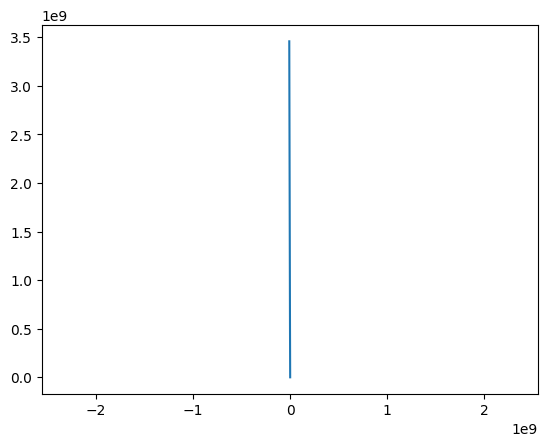

In [22]:
plt.plot(xs, ys)
plt.axis('equal')

Empacarlo en rutina

In [26]:
import ipywidgets as widgets
from ipywidgets import interactive

In [ ]:
def geodesica_nula(r0):
    M = 1
    G = 1

    t0 = 0
    teta0 = np.pi / 2 
    fi0 = 0 

    vr0 = 0.0
    vteta0 = 0 
    vfi0 = C / r0

    T0 = C * t0
    g00 = 1 - 2 * G * M / (C**2 * r0)
    g11 = -1 / (1 - 2 * G * M / (C**2 * r0))
    g22 = - r0**2
    g33 = - r0**2 * np.sin(teta0)**2

    Ut0 = np.sqrt((-g11 * vr0**2 - g22 * vteta0**2 - g33 * vfi0**2) / g00)
    Ur0 = vr0
    Uteta0 = vteta0
    Uphi0 = vfi0

    S = G * M / C**2
    T = S / C

    taus = np.linspace(0, 60 * T, 1000)
    Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0]
    solucion = solve_ivp(edg_schwarzschild, 
                         (taus[0], taus[-1]), 
                         Ys0, 
                         t_eval=taus, 
                         args=(G, M, C), 
                         method='Radau')

    ts = solucion.y[0] / C * UT
    rs = solucion.y[1] * UL
    tetas = solucion.y[2] 
    fis = solucion.y[3] 

    xs = rs * np.sin(tetas) * np.cos(fis)
    ys = rs * np.sin(tetas) * np.sin(fis)
    zs = rs * np.cos(tetas)

    plt.figure()
    plt.plot(xs, ys)
    plt.axis('equal')
    plt.show()

interactive(geodesica_nula, r0=(3, 10, 0.5))


TypeError: interactive.__init__() missing 1 required positional argument: '_interactive__interact_f'

Tiremos varios rayos

In [ ]:
def  deodesica_nula_trayectorias()